# Classic vs grid continuation — trace logs and catalogs

This notebook mirrors **plot_continuation_outputs.ipynb** (magnitude–time, cumulative counts with `set_times` resets, epicenter map) but **compares two runs**: **classic** and **grid** continuation.

## What you need

1. **`TRACE_LOG_DIR`** — folder produced by `run_magnet_continuation_classic_then_grid.py` (contains `run_classic_*`, `run_grid_*`, `run_meta.json`, `pipeline_run_*.json`).
2. **`CLASSIC_CONTINUATION_DIR`** and **`GRID_CONTINUATION_DIR`** — under `outputs/continuation/`, each run now uses **`{model_id}_{inversion_id}_classic`** vs **`_grid`** (see `MAGNET_ETAS_pipeline.py`) so the two `simulated_catalog.csv` files are not overwritten. Point the notebook at those two folders (adjust `_INV` in the path cell if your inversion id differs).

**ETAS parameters by code stage** come from `run_*_etas_params.jsonl` (one JSON object per line: `site`, `parameters`, plus extras). **Mermaid** diagrams below summarize that flow for each mode. **Kernel samples** (`run_*_kernel_samples.json`, optional) are written once per run when `ETAS_SAMPLE_KERNELS=1`.

**Interactive plots:** the **Imports & paths** cell selects the **`widget`** backend (`ipympl`) *before* importing `pyplot`, so magnitude, cumulative, and map figures get a Matplotlib **toolbar** (pan/zoom). Install with `pip install ipympl`, restart the kernel, then **Run All** or run that cell once. Without it, figures fall back to static `inline`.

The first code cell after **Imports & paths** prints **run parameters** and a **re-run command** from `run_meta.json` (included at the top of the HTML report).

Additional diagnostics on the **continuation** segment only:
- overlaid **Δt** histograms (inter-event times in `simulated_catalog.csv`);
- **magnitude vs log₁₀(elapsed seconds)** since forecast start (`timewindow_end`).


In [ ]:
from __future__ import annotations

import html
import json
import os
from pathlib import Path

# HTML report runs (nbconvert) use Agg + explicit display (see _show_figures).
# Avoid inline: it auto-shows open figures at cell end and duplicates _show_figures().
_COMPARE_REPORT = os.environ.get("ETAS_COMPARE_REPORT") == "1"
if _COMPARE_REPORT:
    import matplotlib as _mpl

    _mpl.use("Agg")
else:
    try:
        from IPython import get_ipython

        _ip = get_ipython()
        if _ip is not None:
            _ip.run_line_magic("matplotlib", "widget")
        else:
            raise RuntimeError("No IPython shell")
    except Exception as _mpl_backend_exc:
        import matplotlib as _mpl

        _mpl.use("inline")
        print(
            "matplotlib: using static 'inline'. For pan/zoom: pip install ipympl, restart kernel, run from top.\n",
            f"({type(_mpl_backend_exc).__name__}: {_mpl_backend_exc})",
        )

import matplotlib.pyplot as plt


def _show_figures() -> None:
    """Embed open figures once in HTML reports; interactive runs use plt.show()."""
    if _COMPARE_REPORT:
        import io

        from IPython.display import Image, display

        for _n in list(plt.get_fignums()):
            fig = plt.figure(_n)
            buf = io.BytesIO()
            fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
            display(Image(data=buf.getvalue()))
            plt.close(fig)
    else:
        plt.show()

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

# --- paths (override via env when run from run_magnet_continuation_classic_then_grid.py) ---
REPO_ROOT = Path(
    os.environ.get("ETAS_COMPARE_REPO_ROOT", Path.cwd())
).resolve()

_trace_root = REPO_ROOT / "outputs" / "pipeline_continuation_trace_logs"
if os.environ.get("ETAS_COMPARE_TRACE_LOG_DIR"):
    TRACE_LOG_DIR = Path(os.environ["ETAS_COMPARE_TRACE_LOG_DIR"]).resolve()
elif _trace_root.is_dir():
    _trace_candidates = sorted(
        (d for d in _trace_root.iterdir() if d.is_dir()),
        key=lambda d: d.stat().st_mtime,
        reverse=True,
    )
    TRACE_LOG_DIR = _trace_candidates[0] if _trace_candidates else _trace_root
else:
    TRACE_LOG_DIR = _trace_root

_cont = REPO_ROOT / "outputs" / "continuation"
_latest_grid = sorted(
    _cont.glob("no_magnet_*_grid"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)


def _parse_inv_token(grid_dir: Path) -> str | None:
    name = grid_dir.name
    prefix, suffix = "no_magnet_", "_grid"
    if name.startswith(prefix) and name.endswith(suffix):
        return name[len(prefix) : -len(suffix)]
    return None


ORIGINAL_NAME = "original_catalog.csv"
SIMULATED_NAME = "simulated_catalog.csv"
PIPELINE_CFG = "pipeline_config.json"
INVERSION_CFG = "inversion_config.json"
CONTINUATION_CFG = "continuation_config.json"

PARAMS_CLASSIC = TRACE_LOG_DIR / "run_classic_etas_params.jsonl"
PARAMS_GRID = TRACE_LOG_DIR / "run_grid_etas_params.jsonl"
KERNEL_SAMPLES_CLASSIC = TRACE_LOG_DIR / "run_classic_kernel_samples.json"
KERNEL_SAMPLES_GRID = TRACE_LOG_DIR / "run_grid_kernel_samples.json"
EVENTS_CLASSIC = TRACE_LOG_DIR / "run_classic_events.csv"
EVENTS_GRID = TRACE_LOG_DIR / "run_grid_events.csv"
META_JSON = TRACE_LOG_DIR / "run_meta.json"

_run_meta = None
if META_JSON.is_file():
    with open(META_JSON, "r", encoding="utf-8") as _f:
        _run_meta = json.load(_f)

if os.environ.get("ETAS_COMPARE_INV"):
    _INV = os.environ["ETAS_COMPARE_INV"].strip()
elif _run_meta and _run_meta.get("inversion_id"):
    _INV = str(_run_meta["inversion_id"]).strip()
elif _latest_grid:
    _INV = _parse_inv_token(_latest_grid[0]) or ""
else:
    _INV = ""

if not _INV:
    raise FileNotFoundError(
        "Could not determine inversion id. Set ETAS_COMPARE_INV or run continuation first."
    )

if _run_meta and _run_meta.get("classic_continuation_dir"):
    CLASSIC_CONTINUATION_DIR = Path(_run_meta["classic_continuation_dir"]).resolve()
else:
    CLASSIC_CONTINUATION_DIR = (
        REPO_ROOT / "outputs" / "continuation" / f"no_magnet_{_INV}_classic"
    ).resolve()

if _run_meta and _run_meta.get("grid_continuation_dir"):
    GRID_CONTINUATION_DIR = Path(_run_meta["grid_continuation_dir"]).resolve()
else:
    GRID_CONTINUATION_DIR = (
        REPO_ROOT / "outputs" / "continuation" / f"no_magnet_{_INV}_grid"
    ).resolve()

# --- Run parameters (top of report: recreate this run) ---

_summary = [
    "## Run parameters (recreate)",
    "",
    "Use these settings to reproduce the classic + grid comparison and this report.",
    "",
    f"- **Trace log directory**: `{TRACE_LOG_DIR}`",
    f"- **Inversion id**: `{_INV}`",
    f"- **Classic continuation**: `{CLASSIC_CONTINUATION_DIR}`",
    f"- **Grid continuation**: `{GRID_CONTINUATION_DIR}`",
]

if _run_meta:
    _summary.extend(
        [
            f"- **Created (UTC)**: `{_run_meta.get('created_at_utc', '—')}`",
            f"- **Catalog**: `{_run_meta.get('example_catalog_csv', '—')}`",
            f"- **Base pipeline JSON**: `{_run_meta.get('base_pipeline_json', '—')}`",
            f"- **max_forecast_events**: `{_run_meta.get('max_forecast_events', '—')}`",
            f"- **grid_n_xy**: `{_run_meta.get('grid_n_xy', '—')}`",
            f"- **grid_point_density_km2**: `{_run_meta.get('grid_point_density_km2', '—')}`",
            f"- **magnitude_generator**: `{_run_meta.get('magnitude_generator', '—')}`",
        ]
    )
    _repro = _run_meta.get("reproduce_command")
    if _repro:
        _summary.extend(["", "### Re-run command", "", "```bash", _repro, "```"])
    _summary.extend(
        [
            "",
            "### Full `run_meta.json`",
            "",
            "```json",
            json.dumps(_run_meta, indent=2),
            "```",
        ]
    )
else:
    _summary.append("")
    _summary.append(
        f"*No `{META_JSON.name}` in this trace folder — run "
        "`run_magnet_continuation_classic_then_grid.sh` to generate it.*"
    )

display(Markdown("\n".join(_summary)))


matplotlib: using static 'inline'. For pan/zoom: pip install ipympl, restart kernel, run from top.
 (RuntimeError: 'widget' is not a recognised GUI loop or backend name)


## Run parameters (recreate)

Use these settings to reproduce the classic + grid comparison and this report.

- **Trace log directory**: `/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z`
- **Inversion id**: `020305559f12f9a9`
- **Classic continuation**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_classic`
- **Grid continuation**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_grid`
- **Created (UTC)**: `20260527T164510Z`
- **Catalog**: `/home/neriberman/Repos/etas/input_data/example_catalog.csv`
- **Base pipeline JSON**: `/home/neriberman/Repos/etas/config/pipeline_single_source_repo_default.json`
- **max_forecast_events**: `5000`
- **grid_n_xy**: `None`
- **grid_point_density_km2**: `0.001`
- **magnitude_generator**: `simulate_magnitudes`

### Re-run command

```bash
cd /home/neriberman/Repos/etas && /home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.sh --max-forecast-events 5000 --grid-point-density-km2 0.001
```

### Full `run_meta.json`

```json
{
  "created_at_utc": "20260527T164510Z",
  "trace_log_dir": "/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z",
  "repo_root": "/home/neriberman/Repos/etas",
  "base_pipeline_json": "/home/neriberman/Repos/etas/config/pipeline_single_source_repo_default.json",
  "example_catalog_csv": "/home/neriberman/Repos/etas/input_data/example_catalog.csv",
  "max_forecast_events": 5000,
  "grid_n_xy": null,
  "grid_point_density_km2": 0.001,
  "magnitude_generator": "simulate_magnitudes",
  "python_executable": "/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/bin/python3",
  "cli_argv": [
    "/home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.py",
    "--max-forecast-events=5000",
    "--grid-point-density-km2",
    "1e-3"
  ],
  "reproduce_command": "cd /home/neriberman/Repos/etas && /home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.sh --max-forecast-events 5000 --grid-point-density-km2 0.001",
  "driver_script": "/home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.py",
  "runs": [
    {
      "name": "classic",
      "pipeline_config": "/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z/pipeline_run_classic.json"
    },
    {
      "name": "grid",
      "pipeline_config": "/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z/pipeline_run_grid.json"
    }
  ],
  "inversion_id": "020305559f12f9a9",
  "classic_continuation_dir": "/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_classic",
  "grid_continuation_dir": "/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_grid",
  "comparison_html_report": "/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z/compare_continuation_trace_logs.html"
}
```

### Matplotlib interactivity

The **Imports & paths** cell calls `%matplotlib widget` **before** `import matplotlib.pyplot`, so every figure gets a **toolbar** (pan, zoom, home, save) when `ipympl` is installed (`pip install ipympl`, restart kernel, then **Run All** or run that cell once).

Without `ipympl`, that cell falls back to static **inline** PNGs.


In [2]:
# --- Path / _INV sanity check (latest `no_magnet_*_{classic,grid}` vs notebook) ---
_cont = REPO_ROOT / "outputs" / "continuation"
_latest_grid = sorted(_cont.glob("no_magnet_*_grid"), key=lambda p: p.stat().st_mtime, reverse=True)
display(Markdown("### Path check: `_INV` and continuation folders"))


def _parse_inv_token(grid_dir: Path) -> str | None:
    name = grid_dir.name
    prefix, suffix = "no_magnet_", "_grid"
    if name.startswith(prefix) and name.endswith(suffix):
        return name[len(prefix) : -len(suffix)]
    return None


if _latest_grid:
    auto_inv = _parse_inv_token(_latest_grid[0])
    display(
        Markdown(
            f"- **Most recently modified grid folder**: `{_latest_grid[0]}`\n"
            f"- **Inversion id parsed from that name**: `{auto_inv}`\n"
            f"- **Notebook `_INV`**: `{_INV}` → **match**: **{auto_inv == _INV}**\n"
            f"- **Your `GRID_CONTINUATION_DIR` resolves to**: `{GRID_CONTINUATION_DIR.resolve()}` "
            f"(exists: {GRID_CONTINUATION_DIR.is_dir()})"
        )
    )
    if auto_inv != _INV:
        display(
            Markdown(
                "**Tip:** set `_INV` to the parsed value above, or set "
                "`CLASSIC_CONTINUATION_DIR` / `GRID_CONTINUATION_DIR` explicitly to the folders you intend."
            )
        )
else:
    display(Markdown("*No `no_magnet_*_grid` folders found under `outputs/continuation/`.*"))

for label, d in (
    ("Classic", CLASSIC_CONTINUATION_DIR),
    ("Grid", GRID_CONTINUATION_DIR),
):
    sim = d / SIMULATED_NAME
    n = sum(1 for _ in open(sim)) - 1 if sim.is_file() else -1
    display(Markdown(f"- **{label}** `simulated_catalog.csv` line count (excl. header): **{n}**"))


### Path check: `_INV` and continuation folders

- **Most recently modified grid folder**: `/home/neriberman/Repos/etas/outputs/continuation/no_magnet_020305559f12f9a9_grid`
- **Inversion id parsed from that name**: `020305559f12f9a9`
- **Notebook `_INV`**: `020305559f12f9a9` → **match**: **True**
- **Your `GRID_CONTINUATION_DIR` resolves to**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_grid` (exists: True)

- **Classic** `simulated_catalog.csv` line count (excl. header): **301**

- **Grid** `simulated_catalog.csv` line count (excl. header): **5000**

In [3]:
def _load_json(path: Path) -> dict | None:
    if not path.is_file():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_params_jsonl(path: Path) -> list[dict]:
    if not path.is_file():
        return []
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def first_params_by_site(rows: list[dict]) -> dict[str, dict]:
    """First log line per `site` (parameters + extras except nested copies)."""
    out: dict[str, dict] = {}
    for rec in rows:
        site = rec.get("site")
        if site in out:
            continue
        out[site] = {k: v for k, v in rec.items() if k != "site"}
    return out


def theta_keys_table(
    classic: dict[str, dict], grid: dict[str, dict], sites_order: list[str]
) -> str:
    """Markdown table: ETAS keys vs classic / grid values at first log per site."""
    keys = [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
    lines = [
        "| Stage / site | Key | Classic | Grid |",
        "| --- | --- | --- | --- |",
    ]
    for site in sites_order:
        crec, grec = classic.get(site, {}), grid.get(site, {})
        cpar = crec.get("parameters") if isinstance(crec.get("parameters"), dict) else {}
        gpar = grec.get("parameters") if isinstance(grec.get("parameters"), dict) else {}
        # grid inversion logs full kernel params dict under `parameters`
        for k in keys:
            cv, gv = cpar.get(k), gpar.get(k)
            if cv is None and gv is None:
                continue
            lines.append(
                f"| `{site}` | `{k}` | {cv} | {gv} |"
            )
    return "\n".join(lines)


def format_params_node(params: dict | None, max_lines: int = 6) -> str:
    """Short multi-line label for Mermaid (HTML escaped)."""
    if not params:
        return "(no parameters dict)"
    keys = [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
    lines = []
    for k in keys:
        if k not in params or params[k] is None:
            continue
        v = params[k]
        if isinstance(v, float):
            v = round(v, 6)
        lines.append(f"{k}={v}")
        if len(lines) >= max_lines:
            lines.append("…")
            break
    text = "<br/>".join(html.escape(str(x)) for x in lines)
    return text or "(empty)"


def mermaid_classic_flow(first: dict[str, dict]) -> str:
    sim = first.get("ETASSimulation.simulate", {})
    scc = first.get("simulate_catalog_continuation", {})
    gb = first.get("generate_background_events", {})
    ga = first.get("generate_aftershocks", {})
    p_sim = sim.get("parameters") or {}
    p_scc = scc.get("parameters") or {}
    p_gb = gb.get("parameters") or {}
    p_ga = ga.get("parameters") or {}
    ext_sim = {k: v for k, v in sim.items() if k != "parameters"}
    extras_sim = "<br/>".join(
        f"{html.escape(k)}={html.escape(str(v))}"
        for k, v in sorted(ext_sim.items())
        if v is not None and k in ("continuation_mode", "forecast_n_days", "forecast_start", "forecast_end", "max_forecast_events")
    )
    node_sim = format_params_node(p_sim) + ("<br/>" + extras_sim if extras_sim else "")
    return f'''flowchart TB
    A["ETASSimulation.simulate<br/>{node_sim}"]
    B["simulate_catalog_continuation<br/>{format_params_node(p_scc)}"]
    C["generate_background_events<br/>{format_params_node(p_gb)}"]
    D["generate_aftershocks<br/>{format_params_node(p_ga)}"]
    A --> B --> C --> D
'''


In [4]:
def mermaid_grid_flow(first: dict[str, dict]) -> str:
    sim = first.get("ETASSimulation.simulate", {})
    scg = first.get("simulate_catalog_continuation_grid", {})
    inv = first.get("grid_simulation.run_etas_per_grid_point_inversion", {})
    p_sim = sim.get("parameters") or {}
    p_scg = scg.get("parameters") or {}
    p_inv = inv.get("parameters") or {}
    ext_sim = {k: v for k, v in sim.items() if k != "parameters"}
    extras_sim = "<br/>".join(
        f"{html.escape(k)}={html.escape(str(v))}"
        for k, v in sorted(ext_sim.items())
        if v is not None and k in ("continuation_mode", "forecast_n_days", "forecast_start", "forecast_end", "max_forecast_events")
    )
    node_sim = format_params_node(p_sim) + ("<br/>" + extras_sim if extras_sim else "")
    gp = scg.get("grid_params")
    gp_txt = ""
    if isinstance(gp, dict):
        gp_txt = "<br/>grid_params<br/>" + format_params_node(gp, max_lines=5)
    ext_inv = {k: v for k, v in inv.items() if k != "parameters" and k != "grid_params"}
    extras_inv = "<br/>".join(
        f"{html.escape(k)}={html.escape(str(round(v,4) if isinstance(v,(float,int)) else v))}"
        for k, v in sorted(ext_inv.items())
        if v is not None
    )
    node_inv = format_params_node(p_inv, max_lines=6) + ("<br/>" + extras_inv if extras_inv else "")
    return f'''flowchart TB
    A["ETASSimulation.simulate<br/>{node_sim}"]
    B["simulate_catalog_continuation_grid<br/>{format_params_node(p_scg)}{gp_txt}"]
    C["run_etas_per_grid_point_inversion<br/>{node_inv}"]
    A --> B --> C
'''


In [5]:
trace_dir = TRACE_LOG_DIR.resolve()
display(Markdown("## Trace log folder"))
display(Markdown(f"`{trace_dir}` — exists: **{trace_dir.is_dir()}**"))

meta = _load_json(META_JSON)
if meta:
    display(Markdown("### run_meta.json"))
    print(json.dumps(meta, indent=2))

for name in ("pipeline_run_classic.json", "pipeline_run_grid.json"):
    p = trace_dir / name
    data = _load_json(p)
    display(Markdown(f"### `{name}`"))
    if data is None:
        display(Markdown("*missing*"))
    else:
        scc = data.get("overrides", {}).get("simulate_catalog_continuation", {})
        display(
            Markdown(
                "| Key | Value |\n| --- | --- |\n"
                + "\n".join(f"| `{k}` | `{v}` |" for k, v in sorted(scc.items()))
            )
        )

rows_c = load_params_jsonl(PARAMS_CLASSIC)
rows_g = load_params_jsonl(PARAMS_GRID)
display(Markdown(f"- **Classic** param lines: {len(rows_c)} (`{PARAMS_CLASSIC.name}`)"))
display(Markdown(f"- **Grid** param lines: {len(rows_g)} (`{PARAMS_GRID.name}`)"))

first_c = first_params_by_site(rows_c)
first_g = first_params_by_site(rows_g)

display(Markdown("## ETAS `parameters` dict — first log per `site` (markdown)"))
sites_union = sorted(set(first_c) | set(first_g), key=lambda s: (s.count("."), s))
for site in sites_union:
    display(Markdown(f"### `{site}`"))
    pc = first_c.get(site, {})
    pg = first_g.get(site, {})
    par_c = pc.get("parameters")
    par_g = pg.get("parameters")
    ex_c = {k: v for k, v in pc.items() if k != "parameters"}
    ex_g = {k: v for k, v in pg.items() if k != "parameters"}
    display(
        Markdown(
            "**Classic**\n\n```json\n"
            + json.dumps({"parameters": par_c, **ex_c}, indent=2, default=str)
            + "\n```\n\n**Grid**\n\n```json\n"
            + json.dumps({"parameters": par_g, **ex_g}, indent=2, default=str)
            + "\n```"
        )
    )


## Trace log folder

`/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z` — exists: **True**

### run_meta.json

{
  "created_at_utc": "20260527T164510Z",
  "trace_log_dir": "/home/neriberman/Repos/etas/outputs/pipeline_continuation_trace_logs/20260527T164510Z",
  "repo_root": "/home/neriberman/Repos/etas",
  "base_pipeline_json": "/home/neriberman/Repos/etas/config/pipeline_single_source_repo_default.json",
  "example_catalog_csv": "/home/neriberman/Repos/etas/input_data/example_catalog.csv",
  "max_forecast_events": 5000,
  "grid_n_xy": null,
  "grid_point_density_km2": 0.001,
  "magnitude_generator": "simulate_magnitudes",
  "python_executable": "/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/bin/python3",
  "cli_argv": [
    "/home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.py",
    "--max-forecast-events=5000",
    "--grid-point-density-km2",
    "1e-3"
  ],
  "reproduce_command": "cd /home/neriberman/Repos/etas && /home/neriberman/Repos/etas/runnable_code/run_magnet_continuation_classic_then_grid.sh --max-forecast-events 5000 --grid-poi

### `pipeline_run_classic.json`

...

**Classic**

```json
{
  "parameters": null
}
```

**Grid**

```json
{
  "parameters": {
    "log10_mu": -7.33105975591647,
    "log10_iota": null,
    "log10_k0": -2.449522240330126,
    "a": 1.8147284901476872,
    "log10_c": -3.1123279388711307,
    "omega": -0.0360643447488232,
    "log10_tau": 3.6098916759499717,
    "log10_d": -0.320277070746616,
    "gamma": 1.1908402144983095,
    "rho": 0.6176230718737372
  },
  "grid_params": {
    "mu": 4.66595175628844e-08,
    "beta": 2.3025850929940455,
    "alpha": 1.9,
    "gamma": 1.1908402144983095,
    "c": 0.000772097348687239,
    "p": 0.9639356552511767,
    "D": 0.6916103193081605,
    "q": 1.6176230718737372,
    "m0": 3.5500000000000003,
    "log10_mu": -7.33105975591647,
    "log10_iota": null,
    "log10_k0": -2.449522240330126,
    "a": 1.8147284901476872,
    "log10_c": -3.1123279388711307,
    "omega": -0.0360643447488232,
    "log10_tau": 3.6098916759499717,
    "log10_d": -0.320277070746616,
    "rho": 0.6176230718737372,
    "k0": 0.003552039279336742,
    "tau": 4072.786795097897,
    "d": 0.47832483377353574
  },
  "grid_n_xy": [
    4,
    4
  ],
  "grid_point_density_km2": 0.001,
  "max_forecast_events": 5000,
  "mc": 3.5500000000000003
}
```

### `ETASSimulation.simulate`

**Classic**

```json
{
  "parameters": {
    "log10_mu": -7.33105975591647,
    "log10_iota": null,
    "log10_k0": -2.449522240330126,
    "a": 1.8147284901476872,
    "log10_c": -3.1123279388711307,
    "omega": -0.0360643447488232,
    "log10_tau": 3.6098916759499717,
    "log10_d": -0.320277070746616,
    "gamma": 1.1908402144983095,
    "rho": 0.6176230718737372
  },
  "forecast_n_days": 1000,
  "forecast_start": "2007-01-01 00:00:00",
  "forecast_end": "2009-09-27 00:00:00",
  "continuation_mode": "classic",
  "n_simulations": 1,
  "m_threshold": 3.6,
  "max_forecast_events": 5000,
  "magnitude_generator": "simulate_magnitudes"
}
```

**Grid**

```json
{
  "parameters": {
    "log10_mu": -7.33105975591647,
    "log10_iota": null,
    "log10_k0": -2.449522240330126,
    "a": 1.8147284901476872,
    "log10_c": -3.1123279388711307,
    "omega": -0.0360643447488232,
    "log10_tau": 3.6098916759499717,
    "log10_d": -0.320277070746616,
    "gamma": 1.1908402144983095,
    "rho": 0.6176230718737372
  },
  "forecast_n_days": 1000,
  "forecast_start": "2007-01-01 00:00:00",
  "forecast_end": "2009-09-27 00:00:00",
  "continuation_mode": "grid",
  "n_simulations": 1,
  "m_threshold": 3.6,
  "max_forecast_events": 5000,
  "magnitude_generator": "simulate_magnitudes"
}
```

### `grid_simulation.run_etas_per_grid_point_inversion`

**Classic**

```json
{
  "parameters": null
}
```

**Grid**

```json
{
  "parameters": {
    "mu": 4.66595175628844e-08,
    "beta": 2.3025850929940455,
    "alpha": 1.9,
    "gamma": 1.1908402144983095,
    "c": 0.000772097348687239,
    "p": 0.9639356552511767,
    "D": 0.6916103193081605,
    "q": 1.6176230718737372,
    "m0": 3.5500000000000003,
    "log10_mu": -7.33105975591647,
    "log10_iota": null,
    "log10_k0": -2.449522240330126,
    "a": 1.8147284901476872,
    "log10_c": -3.1123279388711307,
    "omega": -0.0360643447488232,
    "log10_tau": 3.6098916759499717,
    "log10_d": -0.320277070746616,
    "rho": 0.6176230718737372,
    "k0": 0.003552039279336742,
    "tau": 4072.786795097897,
    "d": 0.47832483377353574
  },
  "start_forecast": 1167609600.0,
  "end_forecast": 1254009600.0,
  "n_grid_points": 993,
  "max_forecast_events": 5000,
  "kernel_variant": "default"
}
```

## Parameter flow (Mermaid)

Side-by-side flowcharts: **left = classic**, **right = grid**. Node text is taken from the **first** JSONL record per `site` (same convention as tables above). `generate_aftershocks` repeats every generation in classic mode; only the first snapshot is shown in the node.

**Rendered diagrams:** the next cell also embeds **SVG images** (via [Kroki](https://kroki.io)) so you can see the graphs in environments that do not render ```mermaid``` fenced blocks (for example some VS Code / Jupyter setups).

> If images do not load (offline or blocked), paste the Mermaid blocks into [mermaid.live](https://mermaid.live) or use a JupyterLab Mermaid extension.


In [6]:
import base64
import zlib

mc = mermaid_classic_flow(first_c)
mg = mermaid_grid_flow(first_g)


def _kroki_mermaid_svg_url(diagram: str) -> str:
    """Encode Mermaid text for https://kroki.io (SVG <img>, works without a Mermaid renderer)."""
    z = zlib.compressobj(9, zlib.DEFLATED, zlib.MAX_WBITS)
    payload = z.compress(diagram.encode("utf-8")) + z.flush()
    b64 = base64.urlsafe_b64encode(payload).decode("ascii").rstrip("=")
    return f"https://kroki.io/mermaid/svg/{b64}"


_src_c = _kroki_mermaid_svg_url(mc)
_src_g = _kroki_mermaid_svg_url(mg)
_rendered = f"""
<h4>Rendered flowcharts (Kroki)</h4>
<p style="font-size:12px;color:#333;">SVG images from <a href="https://kroki.io" target="_blank" rel="noopener">kroki.io</a> (needs outbound HTTPS). If they stay blank, use the source table below or open <a href="https://mermaid.live" target="_blank" rel="noopener">mermaid.live</a>.</p>
<table style="width:100%; border-collapse:collapse; table-layout:fixed;">
<colgroup><col style="width:50%"/><col style="width:50%"/></colgroup>
<tr>
<td style="vertical-align:top; border:1px solid #ccc; padding:8px;">
  <div style="font-weight:600;">Classic</div>
  <img src="{_src_c}" alt="classic flowchart" style="max-width:100%; height:auto;" />
</td>
<td style="vertical-align:top; border:1px solid #ccc; padding:8px;">
  <div style="font-weight:600;">Grid</div>
  <img src="{_src_g}" alt="grid flowchart" style="max-width:100%; height:auto;" />
</td>
</tr>
</table>
"""
display(HTML(_rendered))

# Side-by-side source (escaped) for quick comparison in the notebook UI
side_by_side = f"""
<table style="width:100%; border-collapse:collapse; table-layout:fixed;">
<colgroup><col style="width:50%"/><col style="width:50%"/></colgroup>
<tr>
<td style="vertical-align:top; padding:8px; border:1px solid #ccc; font-family:monospace; font-size:10px; white-space:pre-wrap;">{html.escape(mc)}</td>
<td style="vertical-align:top; padding:8px; border:1px solid #ccc; font-family:monospace; font-size:10px; white-space:pre-wrap;">{html.escape(mg)}</td>
</tr>
</table>
"""
display(HTML("<h4>Classic (left) vs grid (right) — Mermaid source</h4>" + side_by_side))

display(Markdown("### Classic — Mermaid (render or paste into mermaid.live)"))
display(Markdown(f"```mermaid\n{mc}\n```"))
display(Markdown("### Grid — Mermaid"))
display(Markdown(f"```mermaid\n{mg}\n```"))


Classic,"Grid <img src=""https://kroki.io/mermaid/svg/eNrNUt1uwiAUvvcpmt7TAa2tXYaJmj2B3pmFnLXoiC0YoG6729PswfYkQ-y07mKXi-QEyPnOz8fH2TT6tXoB46LVfBT5NVvHj6vZcinbrgEntUrs6Soens3dtNFbgnnbMVQkaUpwPvDuMEM0ybJyTGlwAyPJhGQFnQyiKobShBCa9l7dii0whBOc5jjPBpEOOpYmOS4n5ane18dnOCutnFRdoMdbXQu2NbIO0EYbUYF1XKiaUYxL5I0WEcb3wa6DFK_h3TKCfwPWeUmO-QXCxNt1fgtv_NLoIJSzbOxrxE9Bwvk6_tGMV-DAv4ZfUT6zvQk1j2z4Hgy09h9J-e69XIt1bDrFhQPL98LwEx8tleNSHYSxXrLbUcvP1fnvGaHjzM9Yjn2FgO6EUaLhBzASlGO12EDXuD-HJoBq8GrLyjIN3jCFg24kL_K-W6_dLEJoGs3Dvhh9A5D1Kjg"" alt=""grid flowchart"" style=""max-width:100%; height:auto;"" />"


"flowchart TB A[""ETASSimulation.simulate<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>continuation_mode=classic<br/>forecast_end=2009-09-27 00:00:00<br/>forecast_n_days=1000<br/>forecast_start=2007-01-01 00:00:00<br/>max_forecast_events=5000""] B[""simulate_catalog_continuation<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…""] C[""generate_background_events<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…""] D[""generate_aftershocks<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…""] A --> B --> C --> D","flowchart TB A[""ETASSimulation.simulate<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>continuation_mode=grid<br/>forecast_end=2009-09-27 00:00:00<br/>forecast_n_days=1000<br/>forecast_start=2007-01-01 00:00:00<br/>max_forecast_events=5000""] B[""simulate_catalog_continuation_grid<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>grid_params<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>…""] C[""run_etas_per_grid_point_inversion<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>end_forecast=1254009600.0<br/>kernel_variant=default<br/>max_forecast_events=5000<br/>n_grid_points=993<br/>start_forecast=1167609600.0""] A --> B --> C"


### Classic — Mermaid (render or paste into mermaid.live)

```mermaid
flowchart TB
    A["ETASSimulation.simulate<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>continuation_mode=classic<br/>forecast_end=2009-09-27 00:00:00<br/>forecast_n_days=1000<br/>forecast_start=2007-01-01 00:00:00<br/>max_forecast_events=5000"]
    B["simulate_catalog_continuation<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…"]
    C["generate_background_events<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…"]
    D["generate_aftershocks<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…"]
    A --> B --> C --> D

```

### Grid — Mermaid

```mermaid
flowchart TB
    A["ETASSimulation.simulate<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>continuation_mode=grid<br/>forecast_end=2009-09-27 00:00:00<br/>forecast_n_days=1000<br/>forecast_start=2007-01-01 00:00:00<br/>max_forecast_events=5000"]
    B["simulate_catalog_continuation_grid<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>grid_params<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>…"]
    C["run_etas_per_grid_point_inversion<br/>log10_mu=-7.33106<br/>log10_k0=-2.449522<br/>a=1.814728<br/>log10_c=-3.112328<br/>omega=-0.036064<br/>log10_tau=3.609892<br/>…<br/>end_forecast=1254009600.0<br/>kernel_variant=default<br/>max_forecast_events=5000<br/>n_grid_points=993<br/>start_forecast=1167609600.0"]
    A --> B --> C

```

## Shared `theta` keys (classic vs grid, first log only)

Rows appear when at least one side has a `parameters` dict at that `site`.

In [7]:
sites_flow = [
    "ETASSimulation.simulate",
    "simulate_catalog_continuation",
    "simulate_catalog_continuation_grid",
    "generate_background_events",
    "generate_aftershocks",
    "grid_simulation.run_etas_per_grid_point_inversion",
]
sites_flow = [s for s in sites_flow if s in first_c or s in first_g]
display(Markdown(theta_keys_table(first_c, first_g, sites_flow)))


| Stage / site | Key | Classic | Grid |
| --- | --- | --- | --- |
| `ETASSimulation.simulate` | `log10_mu` | -7.33105975591647 | -7.33105975591647 |
| `ETASSimulation.simulate` | `log10_k0` | -2.449522240330126 | -2.449522240330126 |
| `ETASSimulation.simulate` | `a` | 1.8147284901476872 | 1.8147284901476872 |
| `ETASSimulation.simulate` | `log10_c` | -3.1123279388711307 | -3.1123279388711307 |
| `ETASSimulation.simulate` | `omega` | -0.0360643447488232 | -0.0360643447488232 |
| `ETASSimulation.simulate` | `log10_tau` | 3.6098916759499717 | 3.6098916759499717 |
| `ETASSimulation.simulate` | `log10_d` | -0.320277070746616 | -0.320277070746616 |
| `ETASSimulation.simulate` | `gamma` | 1.1908402144983095 | 1.1908402144983095 |
| `ETASSimulation.simulate` | `rho` | 0.6176230718737372 | 0.6176230718737372 |
| `simulate_catalog_continuation` | `log10_mu` | -7.33105975591647 | None |
| `simulate_catalog_continuation` | `log10_k0` | -2.449522240330126 | None |
| `simulate_catalog_continuation` | `a` | 1.8147284901476872 | None |
| `simulate_catalog_continuation` | `log10_c` | -3.1123279388711307 | None |
| `simulate_catalog_continuation` | `omega` | -0.0360643447488232 | None |
| `simulate_catalog_continuation` | `log10_tau` | 3.6098916759499717 | None |
| `simulate_catalog_continuation` | `log10_d` | -0.320277070746616 | None |
| `simulate_catalog_continuation` | `gamma` | 1.1908402144983095 | None |
| `simulate_catalog_continuation` | `rho` | 0.6176230718737372 | None |
| `simulate_catalog_continuation_grid` | `log10_mu` | None | -7.33105975591647 |
| `simulate_catalog_continuation_grid` | `log10_k0` | None | -2.449522240330126 |
| `simulate_catalog_continuation_grid` | `a` | None | 1.8147284901476872 |
| `simulate_catalog_continuation_grid` | `log10_c` | None | -3.1123279388711307 |
| `simulate_catalog_continuation_grid` | `omega` | None | -0.0360643447488232 |
| `simulate_catalog_continuation_grid` | `log10_tau` | None | 3.6098916759499717 |
| `simulate_catalog_continuation_grid` | `log10_d` | None | -0.320277070746616 |
| `simulate_catalog_continuation_grid` | `gamma` | None | 1.1908402144983095 |
| `simulate_catalog_continuation_grid` | `rho` | None | 0.6176230718737372 |
| `generate_background_events` | `log10_mu` | -7.33105975591647 | None |
| `generate_background_events` | `log10_k0` | -2.449522240330126 | None |
| `generate_background_events` | `a` | 1.8147284901476872 | None |
| `generate_background_events` | `log10_c` | -3.1123279388711307 | None |
| `generate_background_events` | `omega` | -0.0360643447488232 | None |
| `generate_background_events` | `log10_tau` | 3.6098916759499717 | None |
| `generate_background_events` | `log10_d` | -0.320277070746616 | None |
| `generate_background_events` | `gamma` | 1.1908402144983095 | None |
| `generate_background_events` | `rho` | 0.6176230718737372 | None |
| `generate_aftershocks` | `log10_mu` | -7.33105975591647 | None |
| `generate_aftershocks` | `log10_k0` | -2.449522240330126 | None |
| `generate_aftershocks` | `a` | 1.8147284901476872 | None |
| `generate_aftershocks` | `log10_c` | -3.1123279388711307 | None |
| `generate_aftershocks` | `omega` | -0.0360643447488232 | None |
| `generate_aftershocks` | `log10_tau` | 3.6098916759499717 | None |
| `generate_aftershocks` | `log10_d` | -0.320277070746616 | None |
| `generate_aftershocks` | `gamma` | 1.1908402144983095 | None |
| `generate_aftershocks` | `rho` | 0.6176230718737372 | None |
| `grid_simulation.run_etas_per_grid_point_inversion` | `log10_mu` | None | -7.33105975591647 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `log10_k0` | None | -2.449522240330126 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `a` | None | 1.8147284901476872 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `log10_c` | None | -3.1123279388711307 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `omega` | None | -0.0360643447488232 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `log10_tau` | None | 3.6098916759499717 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `log10_d` | None | -0.320277070746616 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `gamma` | None | 1.1908402144983095 |
| `grid_simulation.run_etas_per_grid_point_inversion` | `rho` | None | 0.6176230718737372 |

## ETAS kernel samples (optional log)

When `ETAS_SAMPLE_KERNELS=1` (set by `run_magnet_continuation_classic_then_grid.sh`), each run writes **`run_{classic,grid}_kernel_samples.json`** once at the continuation entry site:

- **Classic:** `simulate_catalog_continuation` (inversion θ + `mc`, `beta`)
- **Grid:** `grid_simulation.run_etas_per_grid_point_inversion` (merged `grid_params` + `kernel_variant`)

Each file stores the **logged θ** used for `forecast_intensity.make_kernels`, **analytical curves** on fixed linspace/logspace grids (κ, g, r, inverse spatial **i**), and **random draws** from the same samplers as classic aftershock generation (`simulate_aftershock_time*`, `simulate_aftershock_radius`, G–R magnitudes, `simulate_aftershock_place`).

## Kernel parameters (current run)

### Classic — θ used for kernel plots

- **sample site:** `simulate_catalog_continuation`
- **mc / m0:** `3.5500000000000003`
- **kernel_variant:** `default`
- **random draws:** n=5000, seed=4242, time sampler=`exact`, beta=`2.291304156139075`

| key | value |
| --- | --- |
| `log10_mu` | `-7.33105975591647` |
| `log10_k0` | `-2.449522240330126` |
| `a` | `1.8147284901476872` |
| `log10_c` | `-3.1123279388711307` |
| `omega` | `-0.0360643447488232` |
| `log10_tau` | `3.6098916759499717` |
| `log10_d` | `-0.320277070746616` |
| `gamma` | `1.1908402144983095` |
| `rho` | `0.6176230718737372` |
| `m0` | `3.5500000000000003` |
| `kernel_variant` | `default` |

### Grid — θ used for kernel plots

- **sample site:** `grid_simulation.run_etas_per_grid_point_inversion`
- **mc / m0:** `3.5500000000000003`
- **kernel_variant:** `default`
- **random draws:** n=5000, seed=4242, time sampler=`exact`, beta=`2.3025850929940455`

| key | value |
| --- | --- |
| `log10_mu` | `-7.33105975591647` |
| `log10_k0` | `-2.449522240330126` |
| `a` | `1.8147284901476872` |
| `log10_c` | `-3.1123279388711307` |
| `omega` | `-0.0360643447488232` |
| `log10_tau` | `3.6098916759499717` |
| `log10_d` | `-0.320277070746616` |
| `gamma` | `1.1908402144983095` |
| `rho` | `0.6176230718737372` |
| `beta` | `2.3025850929940455` |
| `m0` | `3.5500000000000003` |
| `kernel_variant` | `default` |

**μ** `4.66595e-08` / `4.66595e-08` · logged sites `simulate_catalog_continuation` / `grid_simulation.run_etas_per_grid_point_inversion`

### Analytical kernel shapes (fixed grids)

### Random kernel draws (simulation samplers)

Same RNG-driven draws as classic aftershock generation: `simulate_aftershock_time*`, `simulate_aftershock_radius`, G–R magnitudes, and `simulate_aftershock_place`.

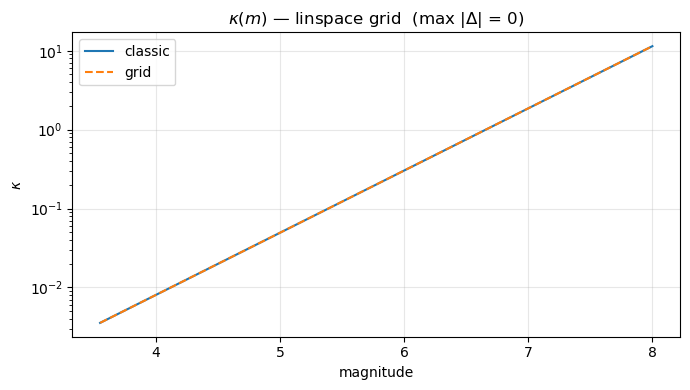

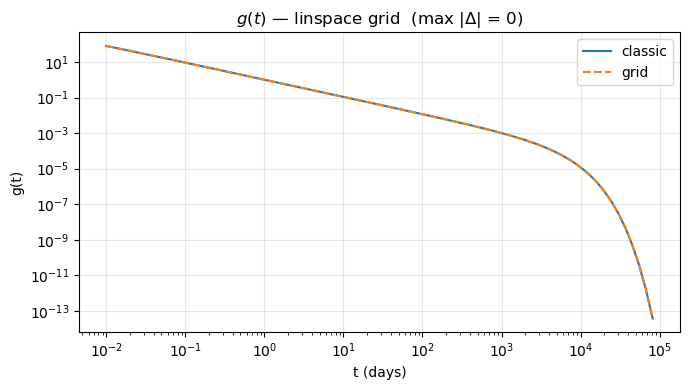

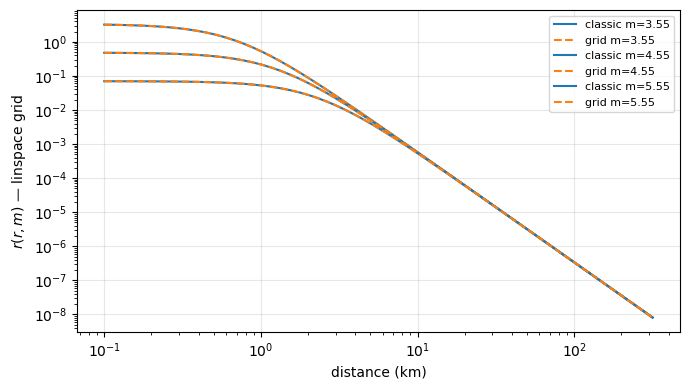

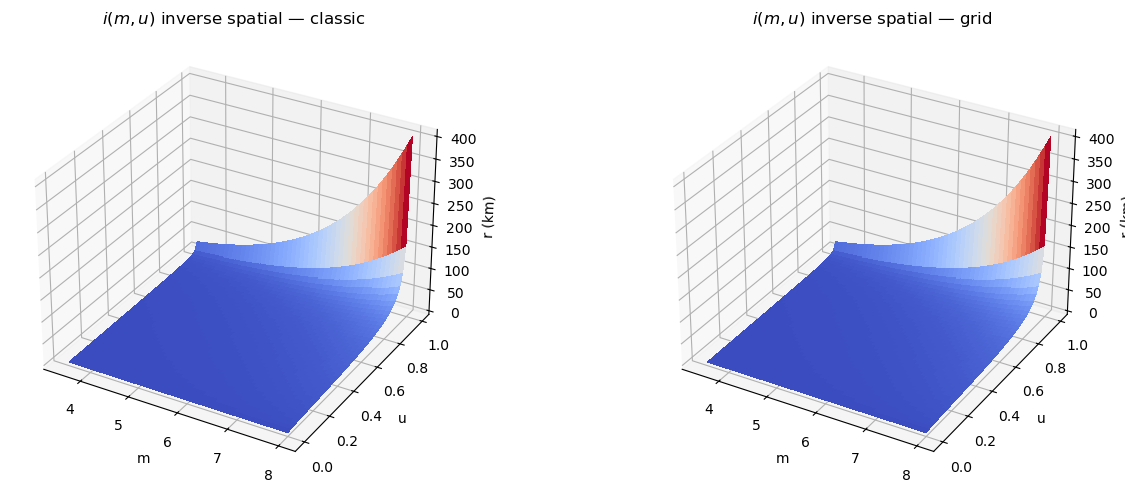

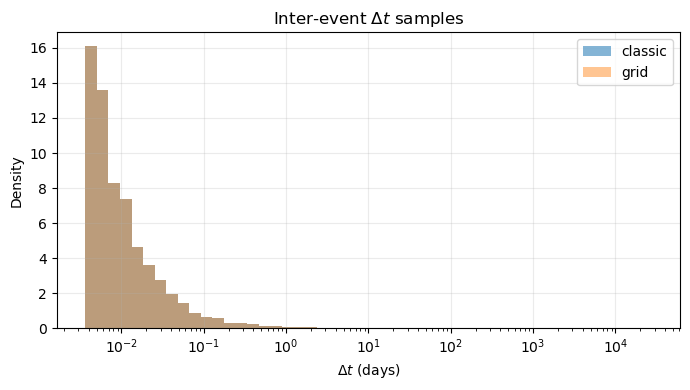

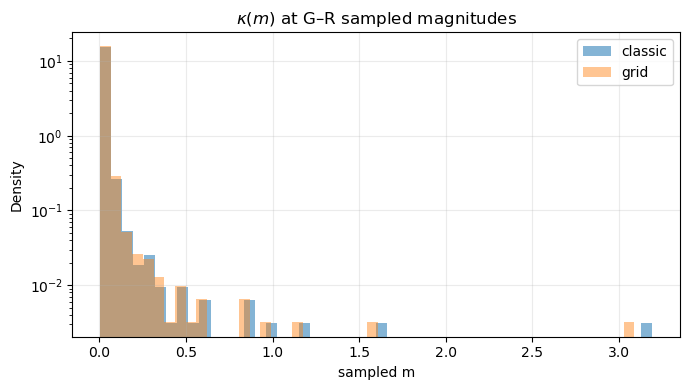

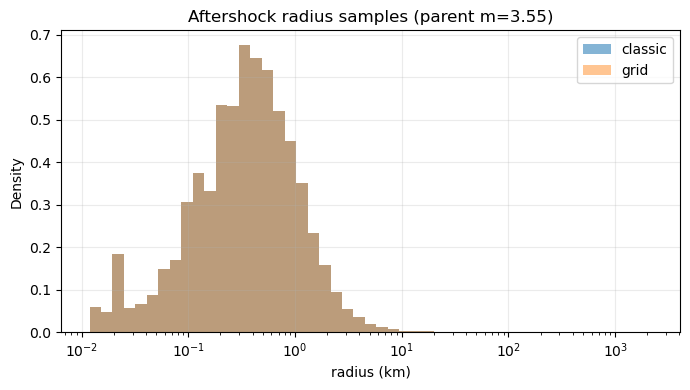

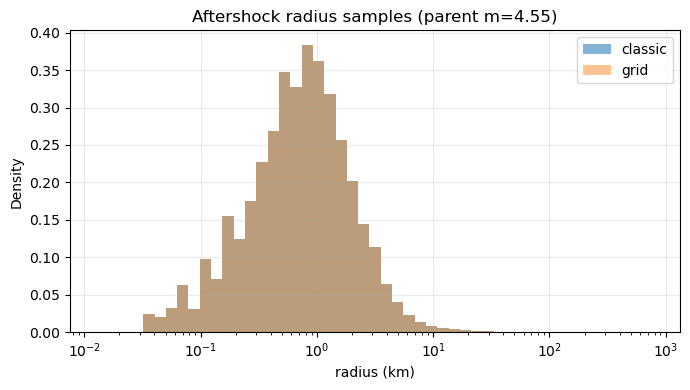

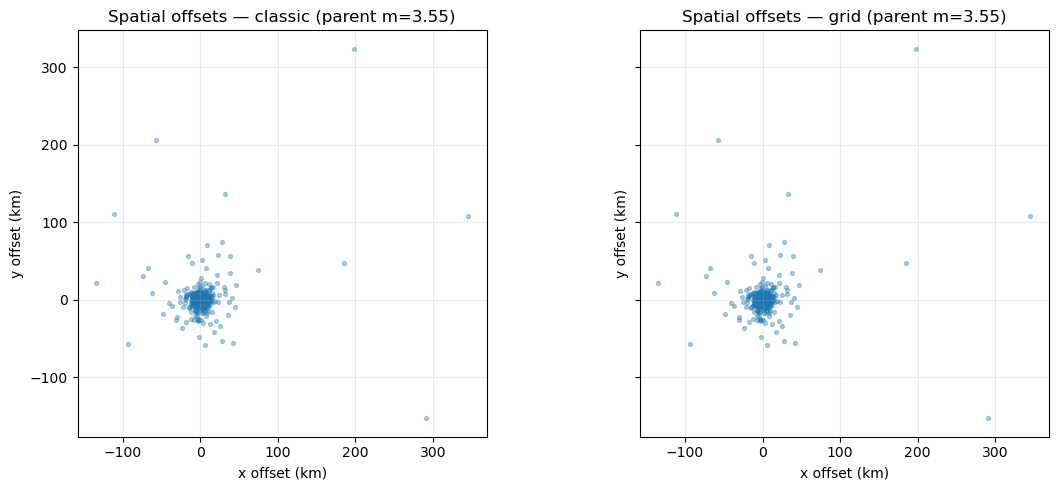

In [8]:
from matplotlib import cm

_KERNEL_THETA_KEYS = (
    "log10_mu",
    "log10_k0",
    "a",
    "log10_c",
    "omega",
    "log10_tau",
    "log10_d",
    "gamma",
    "rho",
    "beta",
    "m0",
    "kernel_variant",
)


def _load_kernel_samples(path: Path) -> dict | None:
    if not path.is_file():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _params_from_jsonl(path: Path, site: str) -> dict | None:
    if not path.is_file():
        return None
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        rec = json.loads(line)
        if rec.get("site") == site:
            return rec.get("parameters")
    return None


def _kernel_run_parameters(ks: dict, jsonl_path: Path) -> dict:
    params = dict(ks.get("parameters") or {})
    if not params:
        fallback = _params_from_jsonl(jsonl_path, ks.get("site", ""))
        if fallback:
            params = dict(fallback)
    if ks.get("kernel_variant") is not None:
        params.setdefault("kernel_variant", ks["kernel_variant"])
    params.setdefault("m0", ks.get("mc"))
    return params


def _kernel_params_markdown(label: str, ks: dict, jsonl_path: Path) -> str:
    params = _kernel_run_parameters(ks, jsonl_path)
    lines = [f"### {label} — θ used for kernel plots", ""]
    lines.append(f"- **sample site:** `{ks.get('site', '—')}`")
    lines.append(f"- **mc / m0:** `{ks.get('mc', '—')}`")
    lines.append(f"- **kernel_variant:** `{params.get('kernel_variant', ks.get('kernel_variant', 'default'))}`")
    if ks.get("random"):
        rnd = ks["random"]
        lines.append(
            f"- **random draws:** n={rnd.get('n', '—')}, seed={rnd.get('seed', '—')}, "
            f"time sampler=`{rnd.get('time_method', '—')}`, beta=`{rnd.get('beta', '—')}`"
        )
    lines.append("")
    lines.append("| key | value |")
    lines.append("| --- | --- |")
    for key in _KERNEL_THETA_KEYS:
        if key in params and params[key] is not None:
            lines.append(f"| `{key}` | `{params[key]}` |")
    return "\n".join(lines)


def _plot_pair(
    title: str,
    x: np.ndarray,
    y_c: np.ndarray,
    y_g: np.ndarray,
    *,
    xlabel: str,
    ylabel: str,
    logx: bool = False,
    logy: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, y_c, label="classic", color="C0")
    ax.plot(x, y_g, label="grid", color="C1", linestyle="--")
    if len(x) == len(y_c) == len(y_g) and len(x) > 0:
        d = float(np.max(np.abs(y_c - y_g)))
        ax.set_title(f"{title}  (max |Δ| = {d:.3g})")
    else:
        ax.set_title(title)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


def _plot_random_hist_pair(
    title: str,
    values_c: np.ndarray,
    values_g: np.ndarray,
    *,
    xlabel: str,
    logx: bool = False,
    logy: bool = False,
    bins: int = 50,
) -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    vc = values_c[np.isfinite(values_c)]
    vg = values_g[np.isfinite(values_g)]
    if len(vc) == 0 and len(vg) == 0:
        ax.set_title(f"{title} (empty)")
        return
    combined = np.concatenate([vc, vg]) if len(vc) and len(vg) else (vc if len(vc) else vg)
    if logx:
        combined = combined[combined > 0]
        vc = vc[vc > 0]
        vg = vg[vg > 0]
        bin_edges = np.logspace(np.log10(max(combined.min(), 1e-6)), np.log10(combined.max()), bins)
    else:
        bin_edges = bins
    if len(vc):
        ax.hist(vc, bins=bin_edges, alpha=0.55, color="C0", density=True, label="classic")
    if len(vg):
        ax.hist(vg, bins=bin_edges, alpha=0.45, color="C1", density=True, label="grid")
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()


def _random_radius_block(radii_km: list, m_parent: float) -> dict:
    for block in radii_km:
        if np.isclose(float(block["m_parent"]), m_parent):
            return block
    raise KeyError(f"m_parent={m_parent} not found in radii_km blocks")


_ks_c = _load_kernel_samples(KERNEL_SAMPLES_CLASSIC)
_ks_g = _load_kernel_samples(KERNEL_SAMPLES_GRID)

if _ks_c is None and _ks_g is None:
    display(
        Markdown(
            "*No kernel sample logs found. Enable with "
            "`run_magnet_continuation_classic_then_grid.sh` "
            f"(`{KERNEL_SAMPLES_CLASSIC.name}`).*"
        )
    )
elif _ks_c is None or _ks_g is None:
    display(
        Markdown(
            f"*Only one side present: classic={_ks_c is not None}, "
            f"grid={_ks_g is not None}.*"
        )
    )
else:
    display(Markdown("## Kernel parameters (current run)"))
    display(Markdown(_kernel_params_markdown("Classic", _ks_c, PARAMS_CLASSIC)))
    display(Markdown(_kernel_params_markdown("Grid", _ks_g, PARAMS_GRID)))

    display(
        Markdown(
            f"**μ** `{_ks_c['mu']:.6g}` / `{_ks_g['mu']:.6g}` · "
            f"logged sites `{_ks_c.get('site')}` / `{_ks_g.get('site')}`"
        )
    )

    display(Markdown("### Analytical kernel shapes (fixed grids)"))
    m = np.asarray(_ks_c["m"])
    _plot_pair(
        r"$\kappa(m)$ — linspace grid",
        m,
        np.asarray(_ks_c["kappa"]),
        np.asarray(_ks_g["kappa"]),
        xlabel="magnitude",
        ylabel=r"$\kappa$",
        logy=True,
    )
    t = np.asarray(_ks_c["t_days"])
    _plot_pair(
        r"$g(t)$ — linspace grid",
        t,
        np.asarray(_ks_c["g"]),
        np.asarray(_ks_g["g"]),
        xlabel="t (days)",
        ylabel="g(t)",
        logx=True,
        logy=True,
    )
    dist = np.asarray(_ks_c["dist_km"])
    fig, ax = plt.subplots(figsize=(7, 4))
    for cc, cg in zip(_ks_c["r_curves"], _ks_g["r_curves"]):
        mf = cc["m"]
        ax.plot(dist, cc["r"], color="C0", label=f"classic m={mf:.2f}")
        ax.plot(dist, cg["r"], color="C1", ls="--", label=f"grid m={mf:.2f}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("distance (km)")
    ax.set_ylabel(r"$r(r,m)$ — linspace grid")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})
    for ax, ks, label in (
        (axes[0], _ks_c, "classic"),
        (axes[1], _ks_g, "grid"),
    ):
        ax.plot_surface(
            np.asarray(ks["m_i"]),
            np.asarray(ks["u_i"]),
            np.asarray(ks["radius_i"]),
            cmap=cm.coolwarm,
            linewidth=0,
            antialiased=False,
        )
        ax.set_title(f"$i(m,u)$ inverse spatial — {label}")
        ax.set_xlabel("m")
        ax.set_ylabel("u")
        ax.set_zlabel("r (km)")
    plt.tight_layout()

    _rnd_c = _ks_c.get("random")
    _rnd_g = _ks_g.get("random")
    if _rnd_c and _rnd_g:
        display(
            Markdown(
                "### Random kernel draws (simulation samplers)\n\n"
                "Same RNG-driven draws as classic aftershock generation: "
                "`simulate_aftershock_time*`, `simulate_aftershock_radius`, "
                "G–R magnitudes, and `simulate_aftershock_place`."
            )
        )
        _plot_random_hist_pair(
            r"Inter-event $\Delta t$ samples",
            np.asarray(_rnd_c["delta_t_days"]),
            np.asarray(_rnd_g["delta_t_days"]),
            xlabel=r"$\Delta t$ (days)",
            logx=True,
        )
        _plot_random_hist_pair(
            r"$\kappa(m)$ at G–R sampled magnitudes",
            np.asarray(_rnd_c["kappa_at_sampled_m"]),
            np.asarray(_rnd_g["kappa_at_sampled_m"]),
            xlabel="sampled m",
            logy=True,
        )
        for m_parent in (float(_ks_c["mc"]), float(_ks_c["mc"]) + 1.0):
            rc = _random_radius_block(_rnd_c["radii_km"], m_parent)
            rg = _random_radius_block(_rnd_g["radii_km"], m_parent)
            _plot_random_hist_pair(
                f"Aftershock radius samples (parent m={m_parent:.2f})",
                np.asarray(rc["radius_km"]),
                np.asarray(rg["radius_km"]),
                xlabel="radius (km)",
                logx=True,
            )
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
        for ax, rnd, label in ((axes[0], _rnd_c, "classic"), (axes[1], _rnd_g, "grid")):
            block = rnd["spatial_xy_km"][0]
            ax.scatter(block["x_km"], block["y_km"], s=8, alpha=0.35)
            ax.set_title(f"Spatial offsets — {label} (parent m={block['m_parent']:.2f})")
            ax.set_xlabel("x offset (km)")
            ax.set_ylabel("y offset (km)")
            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.25)
        plt.tight_layout()
    else:
        display(
            Markdown(
                "*Random kernel draws missing from one or both JSON logs — "
                "re-run `run_magnet_continuation_classic_then_grid.sh` to regenerate "
                "`run_*_kernel_samples.json` with the updated sampler.*"
            )
        )

    _show_figures()


## Catalogs — same plots as `plot_continuation_outputs.ipynb` (classic | grid)

Uses **`original_catalog.csv`** and **`simulated_catalog.csv`** from each continuation folder. **`set_times`** verticals and cumulative resets come from **`pipeline_config.json`** in that folder (fallback: `inversion_config.json`).

In [9]:
root_c = CLASSIC_CONTINUATION_DIR.resolve()
root_g = GRID_CONTINUATION_DIR.resolve()

for label, root in (("Classic", root_c), ("Grid", root_g)):
    display(Markdown(f"### {label} continuation folder"))
    display(Markdown(f"`{root}` — dir: **{root.is_dir()}**"))
    for fn in (ORIGINAL_NAME, SIMULATED_NAME, PIPELINE_CFG, INVERSION_CFG, CONTINUATION_CFG):
        p = root / fn
        display(Markdown(f"- `{fn}`: {'yes' if p.is_file() else 'no'}"))

oc_c, sc_c = root_c / ORIGINAL_NAME, root_c / SIMULATED_NAME
oc_g, sc_g = root_g / ORIGINAL_NAME, root_g / SIMULATED_NAME
assert oc_c.is_file() and sc_c.is_file(), f"Classic catalogs missing under {root_c}"
assert oc_g.is_file() and sc_g.is_file(), f"Grid catalogs missing under {root_g}"

pipeline_c = _load_json(root_c / PIPELINE_CFG)
pipeline_g = _load_json(root_g / PIPELINE_CFG)
inversion_c = _load_json(root_c / INVERSION_CFG)
inversion_g = _load_json(root_g / INVERSION_CFG)

df_oc = pd.read_csv(oc_c)
df_sc = pd.read_csv(sc_c)
df_og = pd.read_csv(oc_g)
df_sg = pd.read_csv(sc_g)

for df, name in (
    (df_oc, "classic original"),
    (df_sc, "classic simulated"),
    (df_og, "grid original"),
    (df_sg, "grid simulated"),
):
    miss = {"latitude", "longitude", "time", "magnitude"} - set(df.columns)
    if miss:
        raise ValueError(f"{name} missing {miss}")

for df in (df_oc, df_sc, df_og, df_sg):
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df["magnitude"] = pd.to_numeric(df["magnitude"], errors="coerce")

print(
    "Row counts — classic orig/sim:", len(df_oc), len(df_sc), "| grid orig/sim:", len(df_og), len(df_sg)
)


### Classic continuation folder

`/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_020305559f12f9a9_classic` — dir: **True**

- `original_catalog.csv`: yes

- `simulated_catalog.csv`: yes

- `pipeline_config.json`: yes

...

- `simulated_catalog.csv`: yes

- `pipeline_config.json`: yes

- `inversion_config.json`: yes

- `continuation_config.json`: yes

Row counts — classic orig/sim: 4454 301 | grid orig/sim: 4454 5000


/tmp/ipykernel_587866/2690144961.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


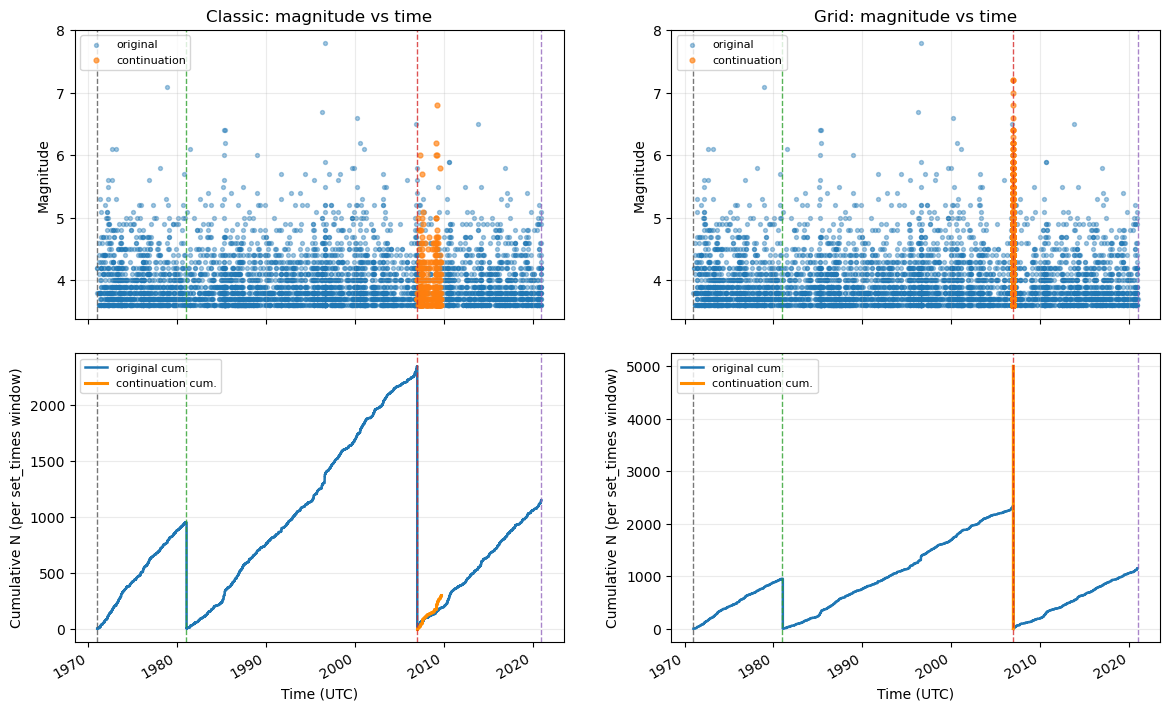

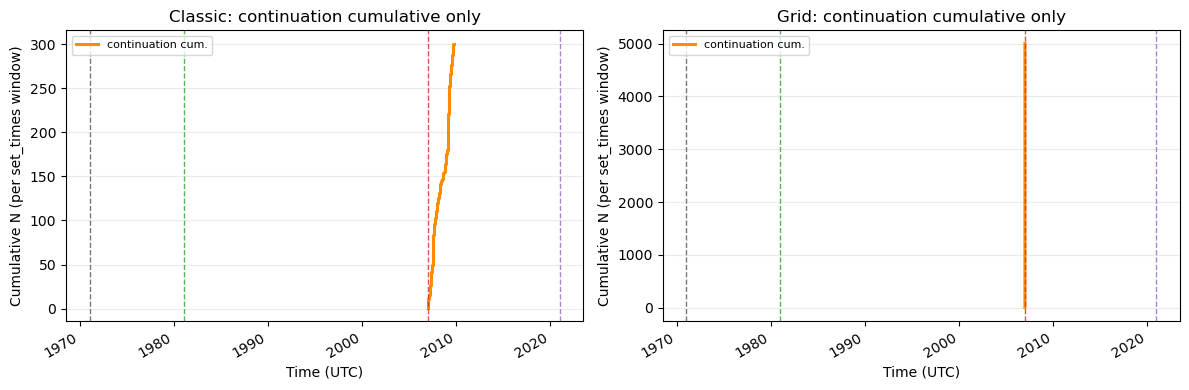

In [10]:
SET_TIME_KEYS = (
    ("auxiliary_start", "#555555"),
    ("timewindow_start", "#2ca02c"),
    ("timewindow_end", "#d62728"),
    ("testwindow_end", "#9467bd"),
)


def set_times_and_resets(pipeline_cfg, inversion_cfg):
    st = None
    if pipeline_cfg:
        st = pipeline_cfg.get("overrides", {}).get("set_times")
    if not st and inversion_cfg:
        st = {k: inversion_cfg[k] for k, _ in SET_TIME_KEYS if k in inversion_cfg}
    reset_ts = []
    if st:
        for key, _ in SET_TIME_KEYS:
            raw = st.get(key)
            if raw is None or raw == "":
                continue
            reset_ts.append(pd.to_datetime(raw, utc=True))
        reset_ts = sorted(set(reset_ts))
    return st, reset_ts


def _cumulative_reset_at_times(sorted_times: pd.Series, reset_ts: list) -> np.ndarray:
    if not reset_ts:
        return np.arange(1, len(sorted_times) + 1, dtype=np.int64)
    out = np.zeros(len(sorted_times), dtype=np.int64)
    ri = 0
    cnt = 0
    for k in range(len(sorted_times)):
        tt = sorted_times.iloc[k]
        while ri < len(reset_ts) and tt >= reset_ts[ri]:
            cnt = 0
            ri += 1
        cnt += 1
        out[k] = cnt
    return out


def add_set_time_vlines(ax, set_times):
    if not set_times:
        return
    for key, color in SET_TIME_KEYS:
        raw = set_times.get(key)
        if raw is None or raw == "":
            continue
        ts = pd.to_datetime(raw, utc=True)
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.0, alpha=0.8, label=key)


st_c, reset_c = set_times_and_resets(pipeline_c, inversion_c)
st_g, reset_g = set_times_and_resets(pipeline_g, inversion_g)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col", gridspec_kw={"hspace": 0.12, "wspace": 0.22})
(ax_mc, ax_mg), (ax_cc, ax_cg) = axes

for ax, df_o, df_s, title in (
    (ax_mc, df_oc, df_sc, "Classic"),
    (ax_mg, df_og, df_sg, "Grid"),
):
    ax.scatter(df_o["time"], df_o["magnitude"], s=8, alpha=0.4, c="tab:blue", label="original")
    ax.scatter(df_s["time"], df_s["magnitude"], s=12, alpha=0.65, c="tab:orange", label="continuation")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{title}: magnitude vs time")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.25)

add_set_time_vlines(ax_mc, st_c)
add_set_time_vlines(ax_mg, st_g)

df_ocs = df_oc.sort_values("time").reset_index(drop=True)
df_scs = df_sc.sort_values("time").reset_index(drop=True)
df_ogs = df_og.sort_values("time").reset_index(drop=True)
df_sgs = df_sg.sort_values("time").reset_index(drop=True)

ax_cc.plot(
    df_ocs["time"],
    _cumulative_reset_at_times(df_ocs["time"], reset_c),
    color="tab:blue",
    lw=1.8,
    drawstyle="steps-post",
    label="original cum.",
)
ax_cc.plot(
    df_scs["time"],
    _cumulative_reset_at_times(df_scs["time"], reset_c),
    color="darkorange",
    lw=2.2,
    drawstyle="steps-post",
    label="continuation cum.",
)
ax_cg.plot(
    df_ogs["time"],
    _cumulative_reset_at_times(df_ogs["time"], reset_g),
    color="tab:blue",
    lw=1.8,
    drawstyle="steps-post",
    label="original cum.",
)
ax_cg.plot(
    df_sgs["time"],
    _cumulative_reset_at_times(df_sgs["time"], reset_g),
    color="darkorange",
    lw=2.2,
    drawstyle="steps-post",
    label="continuation cum.",
)

for ax in (ax_cc, ax_cg):
    ax.set_ylabel("Cumulative N (per set_times window)")
    ax.set_xlabel("Time (UTC)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)

add_set_time_vlines(ax_cc, st_c)
add_set_time_vlines(ax_cg, st_g)

fig.autofmt_xdate()
plt.tight_layout()
_show_figures()

# Continuation cumulative only (same per-window counting as the row above)
fig_cont, (ax_scl, ax_scr) = plt.subplots(1, 2, figsize=(12, 4))
for ax, df_s, st, reset, title in (
    (ax_scl, df_scs, st_c, reset_c, "Classic"),
    (ax_scr, df_sgs, st_g, reset_g, "Grid"),
):
    ax.plot(
        df_s["time"],
        _cumulative_reset_at_times(df_s["time"], reset),
        color="darkorange",
        lw=2.2,
        drawstyle="steps-post",
        label="continuation cum.",
    )
    ax.set_ylabel("Cumulative N (per set_times window)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title(f"{title}: continuation cumulative only")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)
    add_set_time_vlines(ax, st)

fig_cont.autofmt_xdate()
plt.tight_layout()
_show_figures()


## Continuation timing diagnostics

Uses **`simulated_catalog.csv`** only (forecast/continuation events). **Δt** is the UTC gap between consecutive events (sorted by time). **Elapsed** is seconds since forecast start (`timewindow_end` from `set_times`, matching the red marker in the cumulative plots above).


### Inter-event Δt summary

- **Classic**: n_events=301, median Δt=0.661 d, 5–95%=0.001–13.640 d
- **Grid**: n_events=5000, median Δt=0.000 d, 5–95%=0.000–0.000 d

- **Forecast start** (`timewindow_end`): `2007-01-01 00:00:00+00:00` (same for both runs)

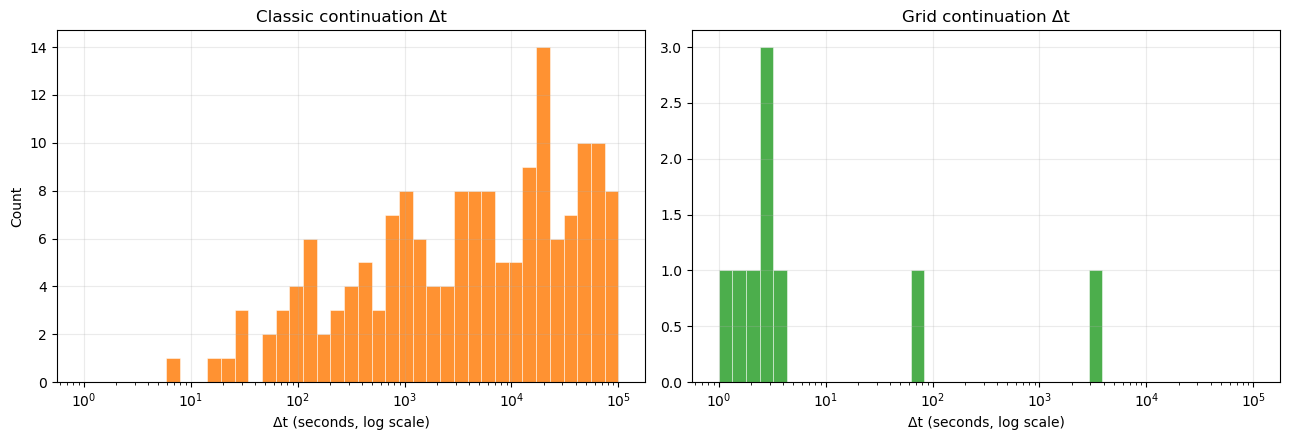

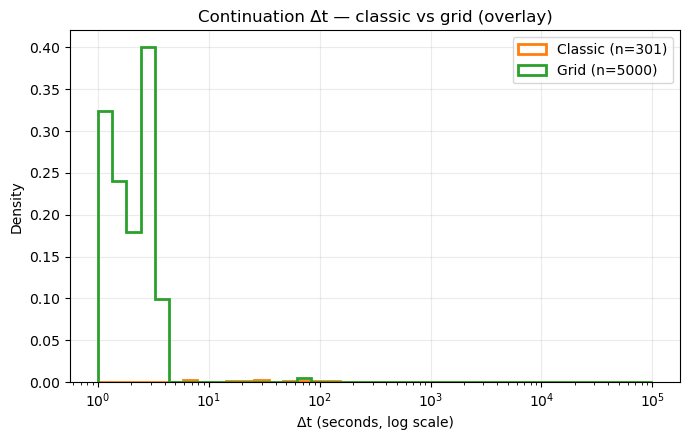

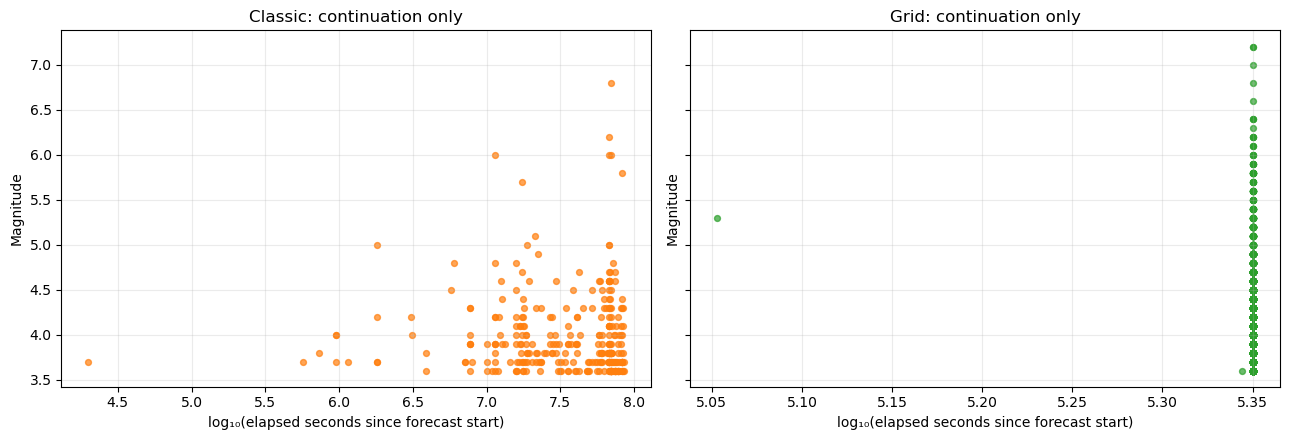

In [11]:
def continuation_forecast_start(pipeline_cfg, inversion_cfg) -> pd.Timestamp:
    st, _ = set_times_and_resets(pipeline_cfg, inversion_cfg)
    raw = (st or {}).get("timewindow_end")
    if raw:
        return pd.to_datetime(raw, utc=True)
    raise ValueError("timewindow_end not found in pipeline/inversion config")


def interevent_seconds(df_cont: pd.DataFrame) -> np.ndarray:
    t = df_cont.sort_values("time")["time"]
    return t.diff().dt.total_seconds().iloc[1:].to_numpy(dtype=float)


def continuation_elapsed_and_mag(
    df_cont: pd.DataFrame, t_start: pd.Timestamp
) -> tuple[np.ndarray, np.ndarray]:
    sub = df_cont.sort_values("time")
    elapsed = (sub["time"] - t_start).dt.total_seconds()
    mask = elapsed >= 0
    return (
        elapsed.loc[mask].to_numpy(dtype=float),
        sub.loc[mask, "magnitude"].to_numpy(dtype=float),
    )


t_start_c = continuation_forecast_start(pipeline_c, inversion_c)
t_start_g = continuation_forecast_start(pipeline_g, inversion_g)

dt_c = interevent_seconds(df_sc)
dt_g = interevent_seconds(df_sg)
el_c, mag_c = continuation_elapsed_and_mag(df_sc, t_start_c)
el_g, mag_g = continuation_elapsed_and_mag(df_sg, t_start_g)

_dt_floor = 1.0  # seconds; avoids log(0) at forecast boundary


def _dt_summary(label: str, dt: np.ndarray) -> str:
    if len(dt) == 0:
        return f"- **{label}**: no inter-event gaps (≤1 event)"
    q = np.quantile(dt, [0.05, 0.5, 0.95])
    return (
        f"- **{label}**: n_events={len(dt) + 1}, "
        f"median Δt={q[1] / 86400:.3f} d, "
        f"5–95%={q[0] / 86400:.3f}–{q[2] / 86400:.3f} d"
    )


display(
    Markdown(
        "### Inter-event Δt summary\n\n"
        + _dt_summary("Classic", dt_c)
        + "\n"
        + _dt_summary("Grid", dt_g)
        + f"\n\n- **Forecast start** (`timewindow_end`): `{t_start_c}` (same for both runs)"
    )
)

fig_dt, axes_dt = plt.subplots(1, 2, figsize=(13, 4.5))
bins_dt = np.logspace(np.log10(max(1.0, min(dt_c.min() if len(dt_c) else 1, dt_g.min() if len(dt_g) else 1))), 5, 40)
if len(dt_c):
    axes_dt[0].hist(dt_c, bins=bins_dt, color="tab:orange", alpha=0.85, edgecolor="white", linewidth=0.4)
axes_dt[0].set_xscale("log")
axes_dt[0].set_xlabel("Δt (seconds, log scale)")
axes_dt[0].set_ylabel("Count")
axes_dt[0].set_title("Classic continuation Δt")
axes_dt[0].grid(True, alpha=0.25)

if len(dt_g):
    axes_dt[1].hist(dt_g, bins=bins_dt, color="tab:green", alpha=0.85, edgecolor="white", linewidth=0.4)
axes_dt[1].set_xscale("log")
axes_dt[1].set_xlabel("Δt (seconds, log scale)")
axes_dt[1].set_title("Grid continuation Δt")
axes_dt[1].grid(True, alpha=0.25)
plt.tight_layout()
_show_figures()

fig_dt_ov, ax_ov = plt.subplots(figsize=(7, 4.5))
if len(dt_c):
    ax_ov.hist(
        dt_c,
        bins=bins_dt,
        density=True,
        histtype="step",
        lw=2,
        color="tab:orange",
        label=f"Classic (n={len(dt_c) + 1})",
    )
if len(dt_g):
    ax_ov.hist(
        dt_g,
        bins=bins_dt,
        density=True,
        histtype="step",
        lw=2,
        color="tab:green",
        label=f"Grid (n={len(dt_g) + 1})",
    )
ax_ov.set_xscale("log")
ax_ov.set_xlabel("Δt (seconds, log scale)")
ax_ov.set_ylabel("Density")
ax_ov.set_title("Continuation Δt — classic vs grid (overlay)")
ax_ov.legend(loc="best")
ax_ov.grid(True, alpha=0.25)
plt.tight_layout()
_show_figures()

fig_mag, axes_mag = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, elapsed, mag, title in (
    (axes_mag[0], el_c, mag_c, "Classic"),
    (axes_mag[1], el_g, mag_g, "Grid"),
):
    x = np.log10(np.maximum(elapsed, _dt_floor))
    ax.scatter(x, mag, s=18, alpha=0.7, c="tab:orange" if "Classic" in title else "tab:green")
    ax.set_xlabel("log₁₀(elapsed seconds since forecast start)")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{title}: continuation only")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
_show_figures()


## Why classic and grid continuation can diverge

The latest driver run (`run_meta.json` in the trace folder) uses the **same** inverted ETAS parameters and forecast window for both modes, but the **generators are different algorithms**, not two draws from an identical point process:

1. **Classic** (`simulate_catalog_continuation`) grows the catalog by **explicit aftershock generations** on the full history. Each generation can add many triggered children; inter-event gaps can be very short when the branching cascade is active. **`max_forecast_events` is not applied** on this path in `ETASSimulation.simulate` — only the grid inverter checks the cap — so classic can produce many more events in the same calendar window.

2. **Grid** (`simulate_catalog_continuation_grid` → `run_etas_per_grid_point_inversion`) treats the forecast as a **single spatio-temporal thinning** problem on a dense UTM lattice (~48k nodes at `grid_point_density_km2=0.05` in the latest run). The accepted event rate is tied to the **aggregated** intensity field; **`max_forecast_events` stops** the run once enough events are accepted. With thinning, long gaps are normal when the total rate is low relative to the classic branching rate.

3. **Spatial representation**: classic triggers in continuous lon/lat with polygon filtering after the fact; grid works in **UTM cells** and updates spatial weights on the lattice. That changes how closely events can cluster in space-time even with the same kernel parameters.

4. **Magnitude sampling** is shared (`simulate_magnitudes`), so magnitude–time differences are driven mainly by **when** events are accepted, not by different G–R draws.

The Δt overlay and log-time magnitude plots above quantify this: if classic’s median Δt is much smaller and its cumulative count rises faster, you are seeing **higher effective productivity** from branching continuation, not a parameter mismatch between the two pipeline JSON files.


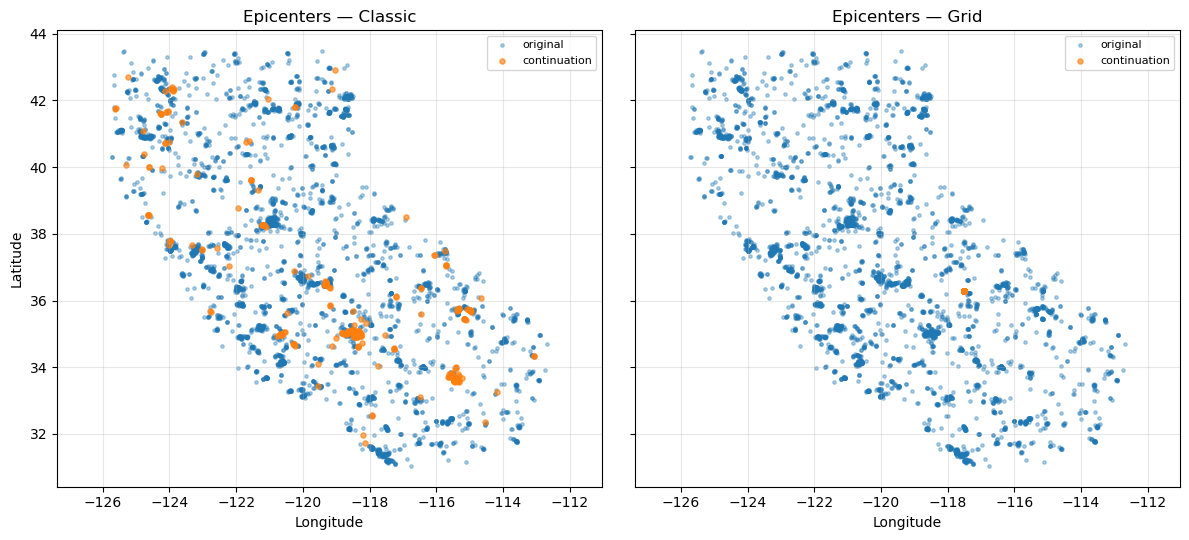

In [12]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

for ax, df_o, df_s, title in (
    (ax_l, df_oc, df_sc, "Classic"),
    (ax_r, df_og, df_sg, "Grid"),
):
    ax.scatter(df_o["longitude"], df_o["latitude"], s=6, alpha=0.35, c="tab:blue", label="original")
    ax.scatter(df_s["longitude"], df_s["latitude"], s=14, alpha=0.65, c="tab:orange", label="continuation")
    ax.set_xlabel("Longitude")
    ax.set_title(f"Epicenters — {title}")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

ax_l.set_ylabel("Latitude")
plt.tight_layout()
_show_figures()


## Trace `events` CSV (optional)

Incremental rows from `generate_background_events`, `generate_aftershocks`, and (grid) `run_etas_per_grid_point_inversion`. **UTM-only** rows have NaN lat/lon until projected later in the pipeline.

- Classic events rows: **301**
- Grid events rows: **5000**

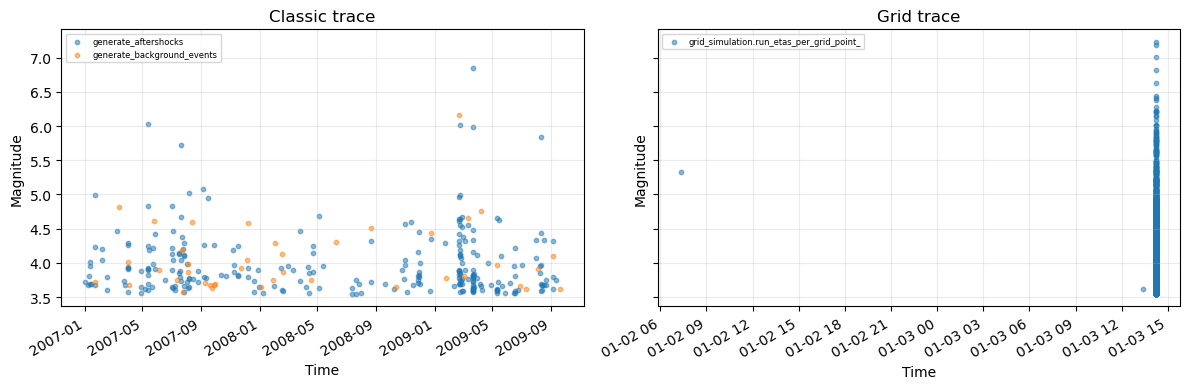

### Per-site row counts (classic)

,n
site,
generate_aftershocks,260
generate_background_events,41


### Per-site row counts (grid)

,n
site,
grid_simulation.run_etas_per_grid_point_inversion,5000


In [13]:
def load_events(path: Path) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame()
    return pd.read_csv(path)


ev_c = load_events(EVENTS_CLASSIC)
ev_g = load_events(EVENTS_GRID)
display(Markdown(f"- Classic events rows: **{len(ev_c)}**\n- Grid events rows: **{len(ev_g)}**"))

if len(ev_c) or len(ev_g):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, ev, title in ((ax1, ev_c, "Classic trace"), (ax2, ev_g, "Grid trace")):
        if len(ev) == 0:
            ax.set_title(f"{title} (empty)")
            continue
        ev = ev.copy()
        ev["time"] = pd.to_datetime(ev["time"], utc=True, errors="coerce")
        for site, sub in ev.groupby("site"):
            ax.scatter(sub["time"], sub["magnitude"], s=10, alpha=0.5, label=str(site)[:40])
        ax.set_xlabel("Time")
        ax.set_ylabel("Magnitude")
        ax.set_title(title)
        ax.legend(fontsize=6, loc="upper left")
        ax.grid(True, alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    _show_figures()

    display(Markdown("### Per-site row counts (classic)"))
    if len(ev_c):
        display(ev_c.groupby("site").size().to_frame("n"))
    display(Markdown("### Per-site row counts (grid)"))
    if len(ev_g):
        display(ev_g.groupby("site").size().to_frame("n"))
